# EV Spare Parts Inventory Analytics

**Course:** Programming for Management Studies  
**Topic:** Demand forecasting and inventory cost analysis for electric-vehicle spare parts

The methods used in this code comes from relevant material covered lectures and homeworks (pandas, numpy, and scikit-learn linear regression)

### The main question
> Can a forecasting method with **low statistical error** still cause **high inventory cost**?


## Step 0 - Upload the data (Colab)

 **Choose Files** and pick `parts.csv`, `demand.csv` and `inventory.csv`. This allows the notebook to read them.

In [34]:
#Upload the three data files. Pick parts.csv, demand.csv, inventory.csv.
try:
    from google.colab import files
    files.upload()
except ModuleNotFoundError:
    print("Not on Colab - just make sure the three CSVs are in this folder.")


## Setup

In [35]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

## Stage 1 & 2 - Load, clean, merge, and compute weekly inventory

We read the three source files, fix a column-name mismatch (`replenishment` -> `replenishment_received`), check for duplicates and missing costs, merge into one table, and compute the weekly inventory numbers from the brief. The code **fails loudly** on bad input, because a silent error here becomes a wrong number in the report.

In [36]:
class DataValidationError(Exception):
    pass


class InventoryAnalytics:

    COST_COLUMNS = ["holding_cost_per_unit_week", "stockout_cost_per_unit"]

    def __init__(self, data_dir="."):
        self.data_dir = data_dir
        self.parts = None
        self.demand = None
        self.inventory = None
        self.merged_data = None

    def load_data(self):
        try:
            self.parts = pd.read_csv(f"{self.data_dir}/parts.csv")
            self.demand = pd.read_csv(f"{self.data_dir}/demand.csv")
            self.inventory = pd.read_csv(f"{self.data_dir}/inventory.csv")
        except FileNotFoundError as error:
            raise DataValidationError(
                f"Could not find an input CSV: {error}. "
                f"Expected parts.csv, demand.csv and inventory.csv in '{self.data_dir}'."
            ) from error

        print(f"Loaded parts={self.parts.shape}, demand={self.demand.shape}, "
              f"inventory={self.inventory.shape}")

    def normalise_column_names(self):
        if "replenishment" in self.inventory.columns and \
           "replenishment_received" not in self.inventory.columns:
            self.inventory = self.inventory.rename(
                columns={"replenishment": "replenishment_received"}
            )
            print("Renamed inventory column 'replenishment' -> 'replenishment_received'.")

        required = {
            "parts": (self.parts, ["part_id"] + self.COST_COLUMNS),
            "demand": (self.demand, ["week_start", "part_id", "units_demanded"]),
            "inventory": (self.inventory, ["week_start", "part_id",
                                           "stock_on_hand", "replenishment_received"]),
        }
        for name, (frame, columns) in required.items():
            missing = [c for c in columns if c not in frame.columns]
            if missing:
                raise DataValidationError(
                    f"{name}.csv is missing required column(s): {missing}. "
                    f"Found: {list(frame.columns)}"
                )

    def clean_data(self):
        self.demand["week_start"] = pd.to_datetime(self.demand["week_start"])
        self.inventory["week_start"] = pd.to_datetime(self.inventory["week_start"])

        for name in ("parts", "demand", "inventory"):
            frame = getattr(self, name)
            duplicates = frame.duplicated().sum()
            if duplicates:
                print(f"{name}: removed {duplicates} exact duplicate row(s).")
                setattr(self, name, frame.drop_duplicates())

        if self.parts["part_id"].duplicated().any():
            raise DataValidationError("parts.csv contains duplicate part_id values.")
        for name in ("demand", "inventory"):
            frame = getattr(self, name)
            if frame.duplicated(subset=["week_start", "part_id"]).any():
                raise DataValidationError(
                    f"{name}.csv contains duplicate (week_start, part_id) pairs."
                )

        missing_costs = self.parts[self.COST_COLUMNS].isna().sum()
        if missing_costs.any():
            raise DataValidationError(
                f"parts.csv has missing cost values:\n{missing_costs}\n"
                "These drive the entire cost analysis and must not be filled "
                "automatically. Decide per column, as a team, and document it."
            )

        missing_demand = self.demand["units_demanded"].isna().sum()
        if missing_demand:
            raise DataValidationError(
                f"demand.csv has {missing_demand} missing units_demanded values."
            )

        print("Cleaning complete. No values imputed.")

    def merge_data(self):
        expected_rows = len(self.demand)
        merged = pd.merge(
            self.demand,
            self.inventory,
            on=["week_start", "part_id"],
            how="inner",
        )
        if len(merged) != expected_rows:
            raise DataValidationError(
                f"Merge changed the row count: {expected_rows} -> {len(merged)}. "
                "demand and inventory do not cover the same part-weeks."
            )

        merged = pd.merge(merged, self.parts, on="part_id", how="left")

        unmatched_parts = merged.loc[merged[self.COST_COLUMNS].isna().any(axis=1),
                                     "part_id"].unique()
        if len(unmatched_parts):
            raise DataValidationError(
                f"These part_ids have no matching row in parts.csv: "
                f"{list(unmatched_parts)}. Their cost columns would be NaN."
            )

        self.merged_data = merged.sort_values(["part_id", "week_start"]).reset_index(drop=True)
        print(f"Merged table: {self.merged_data.shape[0]} rows x "
              f"{self.merged_data.shape[1]} columns "
              f"({self.merged_data['part_id'].nunique()} parts x "
              f"{self.merged_data['week_start'].nunique()} weeks)")

    def calculate_inventory_metrics(self):
        df = self.merged_data

        df["available_inventory"] = df["stock_on_hand"] + df["replenishment_received"]
        df["units_fulfilled"] = np.minimum(df["available_inventory"], df["units_demanded"])
        df["unmet_demand"] = np.maximum(df["units_demanded"] - df["available_inventory"], 0)
        df["ending_stock"] = np.maximum(df["available_inventory"] - df["units_demanded"], 0)
        df["stockout"] = (df["unmet_demand"] > 0).astype(int)

        self.merged_data = df
        self.validate_inventory_metrics()
        print("Stage 2 inventory metrics computed and validated.")

    def validate_inventory_metrics(self):
        df = self.merged_data
        checks = {
            "units_fulfilled <= units_demanded":
                (df["units_fulfilled"] <= df["units_demanded"]).all(),
            "units_fulfilled <= available_inventory":
                (df["units_fulfilled"] <= df["available_inventory"]).all(),
            "unmet_demand >= 0": (df["unmet_demand"] >= 0).all(),
            "ending_stock >= 0": (df["ending_stock"] >= 0).all(),
            "stockout flag matches unmet_demand":
                (df["stockout"] == (df["unmet_demand"] > 0).astype(int)).all(),
            "no NaN in cost columns": df[self.COST_COLUMNS].notna().all().all(),
        }
        failed = [name for name, passed in checks.items() if not passed]
        if failed:
            raise DataValidationError(f"Stage 2 validation failed: {failed}")

    def show_summary(self):
        df = self.merged_data
        print("\n--- Stage 1-2 summary ---")
        print(f"Rows                : {len(df)}")
        print(f"Parts               : {df['part_id'].nunique()}")
        print(f"Weeks               : {df['week_start'].nunique()} "
              f"({df['week_start'].min().date()} to {df['week_start'].max().date()})")
        print(f"Zero-demand weeks   : {(df['units_demanded'] == 0).sum()}")
        print(f"Stockout weeks      : {df['stockout'].sum()} "
              f"({df['stockout'].mean():.1%} of part-weeks)")
        print(f"Total unmet demand  : {df['unmet_demand'].sum():,.0f} units")
        ratio = df["stockout_cost_per_unit"] / df["holding_cost_per_unit_week"]
        print(f"Stockout:holding ratio: min {ratio.min():.0f}x, "
              f"median {ratio.median():.0f}x, max {ratio.max():.0f}x")

    def save_merged_data(self, filename="merged_inventory.csv"):
        self.merged_data.to_csv(f"{self.data_dir}/{filename}", index=False)
        print(f"Saved {filename}")

    def run(self, save=True):
        self.load_data()
        self.normalise_column_names()
        self.clean_data()
        self.merge_data()
        self.calculate_inventory_metrics()
        self.show_summary()
        if save:
            self.save_merged_data()
        return self.merged_data

In [37]:
merged = InventoryAnalytics().run(save=True)
merged.head()

Loaded parts=(24, 10), demand=(1872, 6), inventory=(1872, 4)
Renamed inventory column 'replenishment' -> 'replenishment_received'.
Cleaning complete. No values imputed.
Merged table: 1872 rows x 17 columns (24 parts x 78 weeks)
Stage 2 inventory metrics computed and validated.

--- Stage 1-2 summary ---
Rows                : 1872
Parts               : 24
Weeks               : 78 (2024-01-01 to 2025-06-23)
Zero-demand weeks   : 4
Stockout weeks      : 67 (3.6% of part-weeks)
Total unmet demand  : 558 units
Stockout:holding ratio: min 172x, median 218x, max 314x
Saved merged_inventory.csv


,week_start,part_id,units_demanded,service_center_region,vehicle_type,service_campaign,stock_on_hand,replenishment_received,part_name,category,...,supplier,lead_time_days,demand_trend,holding_cost_per_unit_week,stockout_cost_per_unit,available_inventory,units_fulfilled,unmet_demand,ending_stock,stockout
0,2024-01-01,P001,3,West,Compact EV,0,25,0,Battery Module A,Battery System,...,VoltCore GmbH,21,Increasing,4.92,847.5,25,3,0,22,0
1,2024-01-08,P001,3,West,Compact EV,0,22,0,Battery Module A,Battery System,...,VoltCore GmbH,21,Increasing,4.92,847.5,22,3,0,19,0
2,2024-01-15,P001,4,Central,Compact EV,1,19,0,Battery Module A,Battery System,...,VoltCore GmbH,21,Increasing,4.92,847.5,19,4,0,15,0
3,2024-01-22,P001,4,North,Compact EV,0,15,30,Battery Module A,Battery System,...,VoltCore GmbH,21,Increasing,4.92,847.5,45,4,0,41,0
4,2024-01-29,P001,4,West,Compact EV,0,41,0,Battery Module A,Battery System,...,VoltCore GmbH,21,Increasing,4.92,847.5,41,4,0,37,0


## Stage 3 - Demand forecasting

Five methods, each using only past weeks:

- **pred_naive** - next week = this week
- **pred_ma3** - average of the last 3 weeks
- **pred_ma4** - average of the last 4 weeks
- **pred_reg** - a linear-regression trend per part (scikit-learn, as in Homework 10)
- **pred_reg_safety** - pred_reg plus a safety buffer of 1.5 standard deviations

We split the weeks **70/30 in time order**, fit the regression on the early (train) weeks only, and score on the later (test) weeks - the same train/test idea from the homework. This is how we avoid using the future to predict the past.

In [38]:
TRAIN_FRACTION = 0.70
SAFETY_K = 1.5   # safety stock = SAFETY_K * standard deviation of demand

PREDICTION_COLUMNS = ["pred_naive", "pred_ma3", "pred_ma4", "pred_reg", "pred_reg_safety"]


def add_forecasts(df):
    """Add one forecast column per method, plus rounded (_int) versions."""
    df = df.sort_values(["part_id", "week_start"]).reset_index(drop=True)

    # first 70% of weeks = train, the rest = test (in time order)
    weeks = np.sort(df["week_start"].unique())
    cutoff = weeks[int(len(weeks) * TRAIN_FRACTION) - 1]
    df["split"] = np.where(df["week_start"] <= cutoff, "train", "test")

    week_number, naive, ma3, ma4, reg, safety = [], [], [], [], [], []

    # work one part at a time so every forecast only ever looks at that part's
    # own past weeks
    for part_id, group in df.groupby("part_id"):
        g = group.sort_values("week_start")
        idx = g.index
        demand = g["units_demanded"].tolist()
        n = len(demand)

        # week number 0, 1, 2, ... inside this part (used as the trend feature)
        wk = [i for i in range(n)]

        # naive = last week; moving averages = mean of the last 3 / 4 weeks.
        # We only use weeks before the current one, so early weeks have no value.
        part_naive = [demand[i - 1] if i >= 1 else np.nan for i in range(n)]
        part_ma3 = [sum(demand[i - 3:i]) / 3 if i >= 3 else np.nan for i in range(n)]
        part_ma4 = [sum(demand[i - 4:i]) / 4 if i >= 4 else np.nan for i in range(n)]

        # linear-regression trend: fit on the train weeks only, then predict all
        # weeks (same idea as Homework 10 - model.fit(X_train, y_train)).
        features = pd.DataFrame(
            {"week_number": wk, "service_campaign": g["service_campaign"].tolist()},
            index=idx,
        )
        train_rows = g["split"] == "train"
        model = LinearRegression()
        model.fit(features[train_rows], g.loc[train_rows, "units_demanded"])
        prediction = np.maximum(model.predict(features), 0)   # demand can't be negative

        # safety-stock forecast: regression plus a buffer that grows with how much
        # this part's demand varies (measured on the train weeks only)
        buffer = SAFETY_K * g.loc[train_rows, "units_demanded"].std()
        part_safety = np.maximum(prediction + buffer, 0)

        week_number.append(pd.Series(wk, index=idx))
        naive.append(pd.Series(part_naive, index=idx))
        ma3.append(pd.Series(part_ma3, index=idx))
        ma4.append(pd.Series(part_ma4, index=idx))
        reg.append(pd.Series(prediction, index=idx))
        safety.append(pd.Series(part_safety, index=idx))

    df["week_number"] = pd.concat(week_number)
    df["pred_naive"] = pd.concat(naive)
    df["pred_ma3"] = pd.concat(ma3)
    df["pred_ma4"] = pd.concat(ma4)
    df["pred_reg"] = pd.concat(reg)
    df["pred_reg_safety"] = pd.concat(safety)

    # spare parts are whole units, so round every forecast to an integer
    for col in PREDICTION_COLUMNS:
        df[col + "_int"] = df[col].round()

    # a row can be compared only when every method has produced a value
    df["scoring_window"] = df[PREDICTION_COLUMNS].notna().all(axis=1)
    return df


def evaluate(df):
    """Quick error-vs-cost comparison on the test weeks (Stage 4/5 does the official one)."""
    test = df[(df["scoring_window"]) & (df["split"] == "test")]
    actual = test["units_demanded"]
    holding = test["holding_cost_per_unit_week"]
    stockout = test["stockout_cost_per_unit"]

    print(f"\n--- Test weeks: {len(test)} rows ({test['week_start'].nunique()} weeks), integer forecasts ---")
    print(f"{'method':<18}{'MAE':>8}{'MAPE%':>8}{'MSE':>9}{'bias':>8}{'total cost':>13}")
    for col in PREDICTION_COLUMNS:
        pred = test[col + "_int"]
        error = actual - pred
        mae = error.abs().mean()
        mse = (error ** 2).mean()
        non_zero = actual > 0                                # MAPE skips zero-demand weeks
        mape = (error[non_zero].abs() / actual[non_zero]).mean() * 100
        over = np.maximum(pred - actual, 0)
        under = np.maximum(actual - pred, 0)
        cost = (over * holding + under * stockout).sum()
        bias = (actual - pred).mean()                        # negative = over-forecast
        print(f"{col:<18}{mae:>8.2f}{mape:>8.1f}{mse:>9.1f}{bias:>+8.2f}{cost:>13,.0f}")
    print("\nbias = mean(actual - forecast): negative means the method over-forecasts (holds a buffer).")


def build_reorder_forecast(df):
    """One row per part for Stage 6: next week's forecast + inputs for safety stock."""
    rows = []
    for part_id, group in df.groupby("part_id"):
        g = group.sort_values("week_start")
        week_number = [i for i in range(len(g))]
        features = pd.DataFrame({"week_number": week_number,
                                 "service_campaign": g["service_campaign"].values})
        model = LinearRegression()
        model.fit(features, g["units_demanded"].values)
        next_week = pd.DataFrame({"week_number": [len(g)], "service_campaign": [0]})
        forecast = max(0.0, float(model.predict(next_week)[0]))

        last = g.iloc[-1]
        rows.append({
            "part_id": part_id,
            "part_name": last["part_name"],
            "category": last["category"],
            "current_stock": last["ending_stock"],
            "forecasted_weekly_demand": int(round(forecast)),
            "lead_time_days": last["lead_time_days"],
            "demand_std": round(float(g["units_demanded"].std()), 2),
            "holding_cost_per_unit_week": last["holding_cost_per_unit_week"],
            "stockout_cost_per_unit": last["stockout_cost_per_unit"],
            "demand_trend": last["demand_trend"],
        })
    return pd.DataFrame(rows)

In [39]:
forecasts = add_forecasts(merged)
evaluate(forecasts)

forecasts.to_csv('forecasts.csv', index=False)
reorder = build_reorder_forecast(forecasts)
reorder.to_csv('forecast_for_reorder.csv', index=False)
print('\nSaved forecasts.csv and forecast_for_reorder.csv')


--- Test weeks: 576 rows (24 weeks), integer forecasts ---
method                 MAE   MAPE%      MSE    bias   total cost
pred_naive            4.28    42.5     33.5   -0.02      238,139
pred_ma3              3.49    36.0     21.8   +0.05      200,645
pred_ma4              3.40    34.5     21.0   +0.06      194,488
pred_reg              3.22    33.8     19.1   +0.31      173,815
pred_reg_safety       6.40    76.7     60.1   -6.03       21,463

bias = mean(actual - forecast): negative means the method over-forecasts (holds a buffer).

Saved forecasts.csv and forecast_for_reorder.csv


## Stage 4 & 5 - Evaluation: accuracy vs cost

After forecasting, this stage evualtes the forecasts created where every method was evualted in two main ways:
*   Statistical error (MAE, MAPE, MSE, WAPE, bias)
*   By money (holding cost when we do over-forecasting and stockout cost when we do under forecasting)

However, findings indicate that the two rankings **disagree**.

Bias is `mean(actual - forecast)`:

*   **negative** bias means the method over-forecasts (higher holding costs)
*   **positive** bias means the method under-forecasts (higher stockout costs)



In [40]:
df = pd.read_csv("forecasts.csv") #Load the data into DataFrame

# Keep only the test weeks that are part of scoring window from previous stage
# so all forecasting methods can be compared on the same periods
window = df[(df["scoring_window"]) & (df["split"] == "test")].copy()

# The five forecast methods (integer versions), matching forecasting.py.
methods_to_score = [
    "pred_naive_int",
    "pred_ma3_int",
    "pred_ma4_int",
    "pred_reg_int",
    "pred_reg_safety_int",
]

actual = window["units_demanded"]

# Exclude weeks with zero demand since MAPE cannot be calculated when the actual value is 0.
mape_window = window[window["units_demanded"] > 0]
actual_mape = mape_window["units_demanded"]

print(f"Loaded evaluation window with {len(window)} rows.\n")

results = {}
for col in methods_to_score:
    forecast = window[col]
    forecast_mape = mape_window[col]


    # Squared errors give more weight to larger mistakes
    mse = np.mean((actual - forecast) ** 2)

    # Average size of the forecast error
    mae = np.mean(np.abs(actual - forecast))

    # Percentage error (excluding weeks with zero demand)
    mape = np.mean(np.abs(actual_mape - forecast_mape) / actual_mape) * 100

    # Error relative to total demand volume (Similar to MAPE but can handle when value equal 0 as well)
    wape = (np.abs(actual - forecast).sum() / actual.sum()) * 100

    # Positive = under-forecast, negative = over-forecast
    bias = np.mean(actual - forecast)

    # Calculate the cost of over-forecasting (extra inventory kept in stock, higher holding costs)
    overage = np.maximum(forecast - actual, 0)
    overage_cost = np.sum(overage * window["holding_cost_per_unit_week"])

    # Calculate the cost of under-forecasting (not having enough stock, higher stockout costs)
    underage = np.maximum(actual - forecast, 0)
    underage_cost = np.sum(underage * window["stockout_cost_per_unit"])

    total_cost = overage_cost + underage_cost



    # Amount of demand that can actually be fulfilled
    fulfilled = np.minimum(actual, forecast)
    fill_rate = (fulfilled.sum() / actual.sum()) * 100

    # Store the evaluation results for this forecasting method
    results[col] = {
        "MSE": round(mse, 2),
        "MAE": round(mae, 3),
        "MAPE%": round(mape, 1),
        "WAPE%": round(wape, 1),
        "Bias": round(bias, 2),
        "Total Cost": f"EUR {total_cost:,.2f}",
        "TotalCostEUR": round(total_cost, 2),   # Used a this version for charts
        "Fill Rate": f"{fill_rate:.2f}%",
    }

summary_df = pd.DataFrame(results).T
print(summary_df)

summary_df.to_csv("evaluation_results.csv")
print("\nSaved evaluation_results.csv")
print("\nMost accurate = pred_reg (lowest MAE). Cheapest = pred_reg_safety (lowest cost).")


Loaded evaluation window with 576 rows.

                       MSE    MAE MAPE% WAPE%  Bias      Total Cost  \
pred_naive_int       33.54  4.278  42.5  29.6 -0.02  EUR 238,139.14   
pred_ma3_int         21.83  3.491  36.0  24.2  0.05  EUR 200,644.53   
pred_ma4_int         20.97  3.403  34.5  23.6  0.06  EUR 194,488.12   
pred_reg_int         19.11  3.219  33.8  22.3  0.31  EUR 173,814.75   
pred_reg_safety_int   60.1  6.403  76.7  44.4 -6.03   EUR 21,463.37   

                    TotalCostEUR Fill Rate  
pred_naive_int         238139.14    85.24%  
pred_ma3_int           200644.53    87.73%  
pred_ma4_int           194488.12    87.99%  
pred_reg_int           173814.75    87.78%  
pred_reg_safety_int     21463.37    98.71%  

Saved evaluation_results.csv

Most accurate = pred_reg (lowest MAE). Cheapest = pred_reg_safety (lowest cost).


**Reading the table:** `pred_reg` has the lowest error (MAE 3.22), which makes it statistically the most accurate model, but it has a high cost (~EUR 174k).

`pred_reg_safety` has the worst error (MAE 6.40) but by far the lowest cost (~EUR 21k) and a 98.7% fill rate.

Thus, the most accurate method is **not** the cheapest - because stockouts are so much more expensive than holding stock.

## Stage 6 - Reorder recommendations

We turn the forecast into an action per part: safety stock (1.5 x demand standard deviation, the same buffer idea as Stage 3), a reorder point (expected demand over the lead time plus safety stock), a recommended order quantity, and a plain-language label.

In [41]:
SAFETY_K = 1.5   # safety stock = 1.5 * standard deviation of demand (same as Stage 3)

forecast_df = pd.read_csv("forecast_for_reorder.csv")
weekly_df = pd.read_csv("forecasts.csv")

print(f"forecast_for_reorder.csv : {forecast_df.shape}")
print(f"forecasts.csv            : {weekly_df.shape}")

df = forecast_df.copy()

# Lead time in weeks (the data gives it in days).
df["lead_time_weeks"] = df["lead_time_days"] / 7.0

# Safety stock: a buffer that grows with how much this part's demand varies.
df["safety_stock"] = SAFETY_K * df["demand_std"]

# Reorder point: cover expected demand during the lead time, plus the safety stock.
df["reorder_point"] = df["forecasted_weekly_demand"] * df["lead_time_weeks"] + df["safety_stock"]

# Order enough to get back up to the reorder point (never a negative order).
df["recommended_order_quantity"] = np.maximum(df["reorder_point"] - df["current_stock"], 0)

df["safety_stock"] = df["safety_stock"].round(1)
df["reorder_point"] = df["reorder_point"].round(1)
df["recommended_order_quantity"] = np.ceil(df["recommended_order_quantity"]).astype(int)

print("\nSafety stock / reorder point / order quantity computed.")

# --- Service KPIs per part, from the weekly table -------------------------------
kpi = (
    weekly_df.groupby("part_id")
    .agg(
        stockout_rate=("stockout", "mean"),
        avg_unmet_demand=("unmet_demand", "mean"),
        total_unmet_demand=("unmet_demand", "sum"),
        avg_ending_stock=("ending_stock", "mean"),
        avg_units_fulfilled=("units_fulfilled", "mean"),
        avg_units_demanded=("units_demanded", "mean"),
    )
    .reset_index()
)
kpi["fill_rate"] = kpi["avg_units_fulfilled"] / kpi["avg_units_demanded"]
kpi["stockout_rate"] = kpi["stockout_rate"].round(4)
kpi["fill_rate"] = kpi["fill_rate"].round(4)
kpi["avg_unmet_demand"] = kpi["avg_unmet_demand"].round(2)
kpi["avg_ending_stock"] = kpi["avg_ending_stock"].round(2)

kpi.to_csv("inventory_kpis.csv", index=False)
print(f"Saved inventory_kpis.csv ({kpi.shape[0]} parts)")

df = df.merge(kpi[["part_id", "stockout_rate", "fill_rate"]], on="part_id", how="left")

# Money at risk each week if a part runs out: weekly demand x stockout cost.
# This is a simple, explainable stand-in for "how exposed is this part".
df["weekly_exposure"] = df["forecasted_weekly_demand"] * df["stockout_cost_per_unit"]

# --- Labelling thresholds (top / bottom quartiles) ------------------------------
exposure_q75 = df["weekly_exposure"].quantile(0.75)
holding_cost_q75 = df["holding_cost_per_unit_week"].quantile(0.75)
demand_q25 = df["forecasted_weekly_demand"].quantile(0.25)

print("\nThresholds used for labelling:")
print(f"  exposure top-quartile cutoff      : {exposure_q75:,.1f}")
print(f"  holding cost top-quartile cutoff  : {holding_cost_q75:.2f}")
print(f"  forecasted demand bottom-quartile : {demand_q25:.1f}")


def classify(row):
    # Below the reorder point -> order now, no matter what else is true.
    if row["current_stock"] < row["reorder_point"]:
        return "replenish now"

    # High money-at-risk and only a thin cushion above the reorder point.
    headroom = row["current_stock"] - row["reorder_point"]
    if row["weekly_exposure"] >= exposure_q75 and headroom <= 0.5 * row["reorder_point"]:
        return "high stockout risk"

    # Expensive to hold and barely used -> do not overstock.
    if (row["holding_cost_per_unit_week"] >= holding_cost_q75
            and row["forecasted_weekly_demand"] <= demand_q25):
        return "expensive, low-demand - do not overstock"

    # Sitting on more than twice the reorder point -> overstocked.
    if row["current_stock"] > 2 * row["reorder_point"]:
        return "overstocked"

    return "adequate - monitor"


df["recommendation"] = df.apply(classify, axis=1)

print("\nRecommendation label counts:")
print(df["recommendation"].value_counts())

output_cols = [
    "part_id",
    "part_name",
    "category",
    "current_stock",
    "forecasted_weekly_demand",
    "lead_time_days",
    "safety_stock",
    "reorder_point",
    "recommended_order_quantity",
    "recommendation",
]

output_df = df[output_cols].sort_values("part_id").reset_index(drop=True)
output_df.to_csv("reorder_recommendations.csv", index=False)

print(f"\nSaved reorder_recommendations.csv ({output_df.shape[0]} rows)")
print("\n--- Preview ---")
print(output_df.to_string(index=False))

extended_cols = output_cols + [
    "weekly_exposure",
    "stockout_rate",
    "fill_rate",
    "demand_trend",
    "holding_cost_per_unit_week",
    "stockout_cost_per_unit",
]
df[extended_cols].sort_values("part_id").to_csv("reorder_recommendations_extended.csv", index=False)
print("Saved reorder_recommendations_extended.csv")

forecast_for_reorder.csv : (24, 10)
forecasts.csv            : (1872, 35)

Safety stock / reorder point / order quantity computed.
Saved inventory_kpis.csv (24 parts)

Thresholds used for labelling:
  exposure top-quartile cutoff      : 3,168.6
  holding cost top-quartile cutoff  : 1.47
  forecasted demand bottom-quartile : 7.0

Recommendation label counts:
recommendation
replenish now                               13
adequate - monitor                           7
high stockout risk                           2
expensive, low-demand - do not overstock     2
Name: count, dtype: int64

Saved reorder_recommendations.csv (24 rows)

--- Preview ---
part_id                       part_name              category  current_stock  forecasted_weekly_demand  lead_time_days  safety_stock  reorder_point  recommended_order_quantity                           recommendation
   P001                Battery Module A        Battery System             30                         8              21           4.2

## Stage 7 - Charts (dashboard)

Visual summary of the finding. These run in Colab (matplotlib). Each chart is
saved as a PNG so it drops straight into the slides. Six charts:

1. Accuracy (MAE) vs total cost per method - the two side-by-side bars.
2. The trade-off scatter - the most accurate point is not the cheapest.
3. Cost breakdown - holding vs stockout money for each method.
4. Fill rate per method - the safety method reaches 98.7%.
5. Reorder recommendation counts across the 24 parts.
6. One example part over time - the safety buffer sitting above demand.


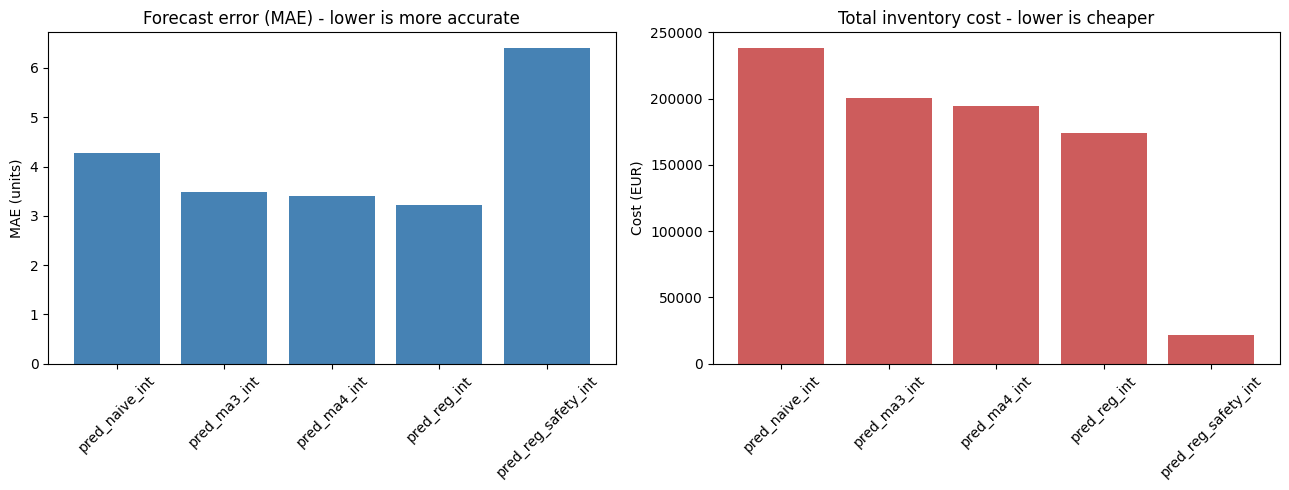

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.read_csv('evaluation_results.csv', index_col=0)
results['CostNum'] = results['TotalCostEUR']   # numeric cost saved by the evaluation stage

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1) accuracy (MAE) per method
axes[0].bar(results.index, results['MAE'], color='steelblue')
axes[0].set_title('Forecast error (MAE) - lower is more accurate')
axes[0].set_ylabel('MAE (units)')
axes[0].tick_params(axis='x', rotation=45)

# 2) cost per method
axes[1].bar(results.index, results['CostNum'], color='indianred')
axes[1].set_title('Total inventory cost - lower is cheaper')
axes[1].set_ylabel('Cost (EUR)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart_accuracy_vs_cost.png', dpi=120, bbox_inches='tight')
plt.show()

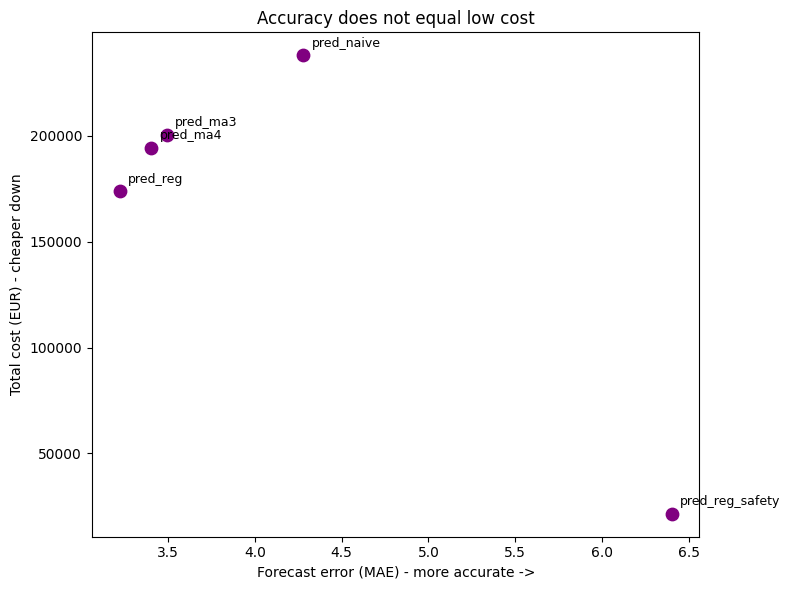

In [43]:
# The trade-off in one chart: accuracy on x, cost on y. The most accurate point
# (pred_reg, bottom-left on error) is NOT the cheapest (pred_reg_safety, far lower cost).
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results['MAE'], results['CostNum'], s=80, color='purple')
for name, row in results.iterrows():
    ax.annotate(name.replace('_int', ''), (row['MAE'], row['CostNum']),
                textcoords='offset points', xytext=(6, 6), fontsize=9)
ax.set_xlabel('Forecast error (MAE) - more accurate ->')
ax.set_ylabel('Total cost (EUR) - cheaper down')
ax.set_title('Accuracy does not equal low cost')
plt.tight_layout()
plt.savefig('chart_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()

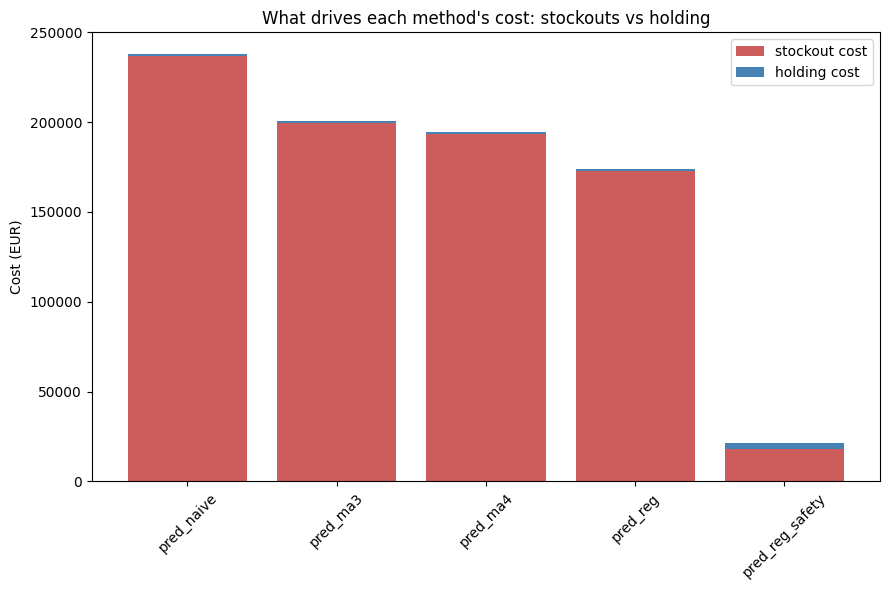

In [44]:
# Chart 3: what each method's cost is made of - stockout money vs holding money.
# We recompute the split exactly the way the evaluation stage does, on the same
# test weeks, so the totals match the table above.
window = forecasts[(forecasts["scoring_window"]) & (forecasts["split"] == "test")]
actual = window["units_demanded"]
methods = ["pred_naive_int", "pred_ma3_int", "pred_ma4_int", "pred_reg_int", "pred_reg_safety_int"]

holding_cost, stockout_cost = [], []
for col in methods:
    forecast = window[col]
    over = np.maximum(forecast - actual, 0)      # forecast too high -> we hold spares
    under = np.maximum(actual - forecast, 0)     # forecast too low -> we run out
    holding_cost.append((over * window["holding_cost_per_unit_week"]).sum())
    stockout_cost.append((under * window["stockout_cost_per_unit"]).sum())

labels = [m.replace("_int", "") for m in methods]
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(labels, stockout_cost, color="indianred", label="stockout cost")
ax.bar(labels, holding_cost, bottom=stockout_cost, color="steelblue", label="holding cost")
ax.set_title("What drives each method's cost: stockouts vs holding")
ax.set_ylabel("Cost (EUR)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("chart_cost_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()

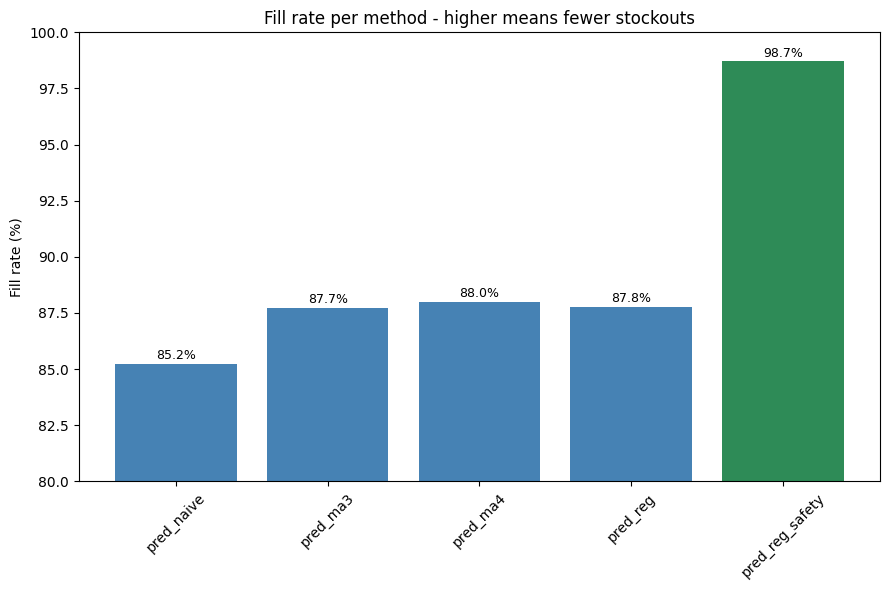

In [45]:
# Chart 4: fill rate per method - the share of demand we could actually meet.
# The safety method is highlighted because it is the one that reaches 98.7%.
fill = results["Fill Rate"].str.replace("%", "", regex=False).astype(float)
names = [i.replace("_int", "") for i in fill.index]
colors = ["seagreen" if i == "pred_reg_safety_int" else "steelblue" for i in fill.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(names, fill.values, color=colors)
ax.set_title("Fill rate per method - higher means fewer stockouts")
ax.set_ylabel("Fill rate (%)")
ax.set_ylim(80, 100)
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(fill.values):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("chart_fill_rate.png", dpi=120, bbox_inches="tight")
plt.show()


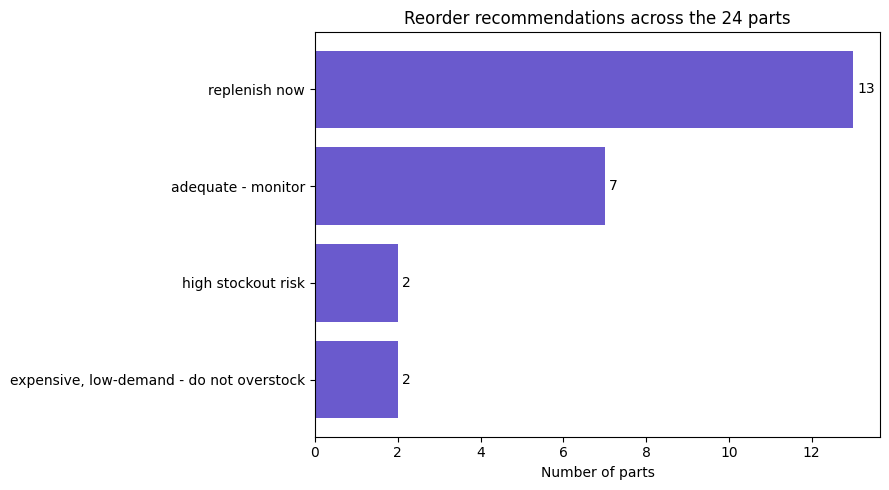

In [46]:
# Chart 5: how the 24 parts split across the action labels (Stage 6 output).
# Horizontal bars so the longer labels stay readable.
recs = pd.read_csv("reorder_recommendations.csv")
counts = recs["recommendation"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(counts.index, counts.values, color="slateblue")
ax.set_title("Reorder recommendations across the 24 parts")
ax.set_xlabel("Number of parts")
for i, v in enumerate(counts.values):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=10)
plt.tight_layout()
plt.savefig("chart_recommendation_counts.png", dpi=120, bbox_inches="tight")
plt.show()


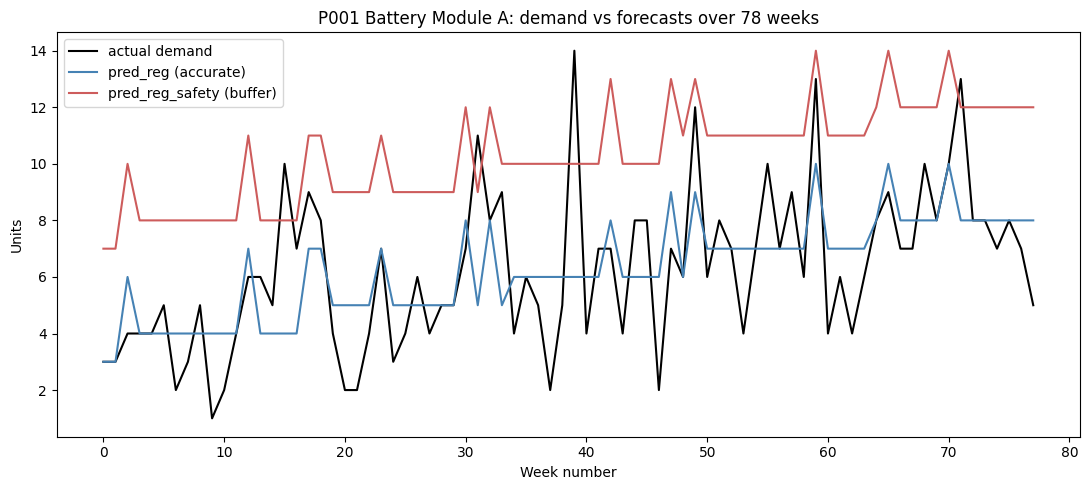

In [47]:
# Chart 6: one part over time - actual demand vs the accurate forecast vs the
# safety forecast. The red safety line sits above demand on purpose: that gap is
# the buffer that stops expensive stockouts. P001 has the highest stockout cost.
part = "P001"
one = forecasts[forecasts["part_id"] == part].sort_values("week_start")
name = one["part_name"].iloc[0]

fig, ax = plt.subplots(figsize=(11, 5))
weeks = range(len(one))
ax.plot(weeks, one["units_demanded"], color="black", label="actual demand")
ax.plot(weeks, one["pred_reg_int"], color="steelblue", label="pred_reg (accurate)")
ax.plot(weeks, one["pred_reg_safety_int"], color="indianred", label="pred_reg_safety (buffer)")
ax.set_title(f"{part} {name}: demand vs forecasts over 78 weeks")
ax.set_xlabel("Week number")
ax.set_ylabel("Units")
ax.legend()
plt.tight_layout()
plt.savefig("chart_example_part.png", dpi=120, bbox_inches="tight")
plt.show()

## Conclusion

### The main question
> Can a forecasting method with **low statistical error** still cause **high inventory cost**?

### The answer
**Yes.** Minimising forecast error makes a forecast aim at the *average* demand. But in this data a stockout costs **172-314x** more than holding a spare for a week, so a forecast that deliberately keeps a **safety buffer** is less accurate yet far cheaper. That trade-off/ dilemma is the whole project.

- The most **accurate** forecast (`pred_reg`, MAE 3.22) is **not** the **cheapest**.
- The cheapest forecast (`pred_reg_safety`, ~EUR 21k vs ~EUR 174k) wins because it holds a safety buffer, trading accuracy for protection against expensive stockouts.
- **Why:** in this data a stockout costs 172-314x a week of holding, so having a stockout is far more penalized than being having extra inventories.
